In [1]:
import numpy as np
import pandas as pd

import os

import torch
import torch.nn as nn
import torch.nn.functional as F

import torchvision
from torchvision.datasets import ImageFolder

from torch.utils.data.dataloader import DataLoader
from torch.utils.data import Dataset
from torch.utils.data import Subset

import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import random
from PIL import Image

%matplotlib inline
torch.manual_seed(0)

from torchvision import models
from torch.optim import lr_scheduler
from sklearn.metrics import confusion_matrix
import seaborn as sns
import itertools
import copy

In [2]:
torch.xpu.is_available()  # torch.xpu — это API для поддержки графических процессоров Intel

True

In [3]:
# КОД для графического процессора Intel
tensor = torch.tensor([1.0, 2.0]).to("xpu")

In [4]:
# Проверка доступности Intel GPU
if torch.xpu.is_available():
    device = torch.device("xpu")
    print("Training on Intel GPU...")
else:
    device = torch.device("cpu")
    print("Training on CPU...")

Training on Intel GPU...


In [5]:
train_transform = torchvision.transforms.Compose([
    torchvision.transforms.Resize((224, 224)),
    torchvision.transforms.RandomHorizontalFlip(),
    torchvision.transforms.RandomRotation(10),
    torchvision.transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = torchvision.transforms.Compose([
    torchvision.transforms.Resize((224, 224)),
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transform = torchvision.transforms.Compose([
    torchvision.transforms.Resize(size=(224, 224)),
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # Normalizing the data to the data that the ResNet18 was trained on
    
])

In [6]:
train_val_path="Dataset"

train_dataset = ImageFolder(train_val_path, transform=train_transform)
val_dataset = ImageFolder(train_val_path, transform=val_transform)

class_names = train_dataset.classes
print(class_names) # list out all the classes

['COVID', 'Lung_Opacity', 'Normal', 'Viral Pneumonia']


In [7]:
# Splitting the data into train and validation set
def split_train_val(tot_img, val_percentage=0.2, rnd=23):
    # Here indices are randomly permuted 
    number_of_val = int(tot_img*val_percentage)
    
    np.random.seed(rnd)
    indexs = np.random.permutation(tot_img)
    return indexs[0:number_of_val], indexs[number_of_val:]

randomness = 1
val_per = 0.2

all_len = len(train_dataset)

val_indices, train_indices = split_train_val(all_len, val_per, randomness)

print(val_indices, "validation data:", val_indices.shape)
print(train_indices, "train data:", train_indices.shape)

[19979 12663  9039 ... 14582  5990 18306] validation data: (4193,)
[ 6371   319  1041 ...  5192 12172   235] train data: (16772,)


In [8]:
train_dataset = Subset(train_dataset, train_indices)
val_dataset = Subset(val_dataset, val_indices)

In [9]:
batch_size = 128

train_dataloader = DataLoader(train_dataset, batch_size, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size, shuffle=False)

In [10]:
model = models.resnet18(pretrained=True)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 4)  # 4 класса
model = model.to(device)

In [11]:
# Определение функции потерь и оптимизатора
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=3e-5)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

In [12]:
# Функция для обучения модели с выводом loss и accuracy каждые 20 шагов
def train_model(model, criterion, optimizer, scheduler, num_epochs=2):
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
    train_losses, val_losses = [], []
    train_accuracies, val_accuracies = [], []

    print("Starting training...")

    for epoch in range(num_epochs):
        print(f'\nEpoch {epoch + 1}/{num_epochs}')
        print('-' * 10)

        # Каждая эпоха имеет фазы обучения и валидации
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()  # Устанавливаем модель в режим обучения
                print("Training phase...")
            else:
                model.eval()  # Устанавливаем модель в режим валидации
                print("Validation phase...")

            running_loss = 0.0
            running_corrects = 0

            # Итерация по данным
            for step, (inputs, labels) in enumerate(train_dataloader if phase == 'train' else val_dataloader):
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()  # Обнуляем градиенты

                # Прямой проход
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    # Обратный проход и оптимизация только в фазе обучения
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                # Сбор статистики
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

                # Вывод информации каждые 20 шагов
                if phase == 'train' and step % 20 == 0:
                    # Вычисляем accuracy на текущем батче
                    batch_acc = torch.sum(preds == labels.data).double() / inputs.size(0)
                    print(f'Step {step}: Loss: {loss.item():.4f}, Accuracy: {batch_acc:.4f}')

            # Вычисление потерь и точности для текущей эпохи
            epoch_loss = running_loss / (len(train_dataset) if phase == 'train' else len(val_dataset))
            epoch_acc = running_corrects.double() / (len(train_dataset) if phase == 'train' else len(val_dataset))

            if phase == 'train':
                train_losses.append(epoch_loss)
                train_accuracies.append(epoch_acc.cpu().item())  # Перемещаем на CPU и преобразуем в число
                print(f'Train Loss: {epoch_loss:.4f}, Train Acc: {epoch_acc:.4f}')
            else:
                val_losses.append(epoch_loss)
                val_accuracies.append(epoch_acc.cpu().item())  # Перемещаем на CPU и преобразуем в число
                print(f'Validation Loss: {epoch_loss:.4f}, Validation Acc: {epoch_acc:.4f}')

                # Сохранение лучшей модели
                if epoch_acc > best_acc:
                    best_acc = epoch_acc
                    best_model_wts = copy.deepcopy(model.state_dict())
                    print(f'New best model found with accuracy: {best_acc:.4f}')

        # Обновление learning rate
        if phase == 'train':
            scheduler.step()

    print(f'\nTraining complete. Best validation accuracy: {best_acc:.4f}')

    # Загрузка весов лучшей модели
    model.load_state_dict(best_model_wts)

    # Построение графиков потерь и точности
    plt.figure(figsize=(12, 5))

    # График потерь
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Loss over Epochs')
    plt.legend()

    # График точности
    plt.subplot(1, 2, 2)
    plt.plot(train_accuracies, label='Train Accuracy')
    plt.plot(val_accuracies, label='Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Accuracy over Epochs')
    plt.legend()

    plt.show()

    # Построение матрицы ошибок для валидационной выборки
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in val_dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())  # Перемещаем на CPU и преобразуем в NumPy
            all_labels.extend(labels.cpu().numpy())  # Перемещаем на CPU и преобразуем в NumPy

    # Вычисление матрицы ошибок
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()

    return model, train_losses, val_losses, train_accuracies, val_accuracies

Starting training...

Epoch 1/10
----------
Training phase...
Step 0: Loss: 1.2670, Accuracy: 0.4844
Step 20: Loss: 0.6641, Accuracy: 0.7656
Step 40: Loss: 0.3544, Accuracy: 0.8984
Step 60: Loss: 0.3666, Accuracy: 0.8984
Step 80: Loss: 0.3105, Accuracy: 0.9219
Step 100: Loss: 0.3185, Accuracy: 0.8984
Step 120: Loss: 0.3727, Accuracy: 0.8516
Train Loss: 0.4888, Train Acc: 0.8337
Validation phase...
Validation Loss: 0.2865, Validation Acc: 0.8977
New best model found with accuracy: 0.8977

Epoch 2/10
----------
Training phase...
Step 0: Loss: 0.3095, Accuracy: 0.8984
Step 20: Loss: 0.2012, Accuracy: 0.9297
Step 40: Loss: 0.2429, Accuracy: 0.9219
Step 60: Loss: 0.2044, Accuracy: 0.9297
Step 80: Loss: 0.2521, Accuracy: 0.9141
Step 100: Loss: 0.3417, Accuracy: 0.8906
Step 120: Loss: 0.1964, Accuracy: 0.9219
Train Loss: 0.2490, Train Acc: 0.9137
Validation phase...
Validation Loss: 0.2218, Validation Acc: 0.9239
New best model found with accuracy: 0.9239

Epoch 3/10
----------
Training phase

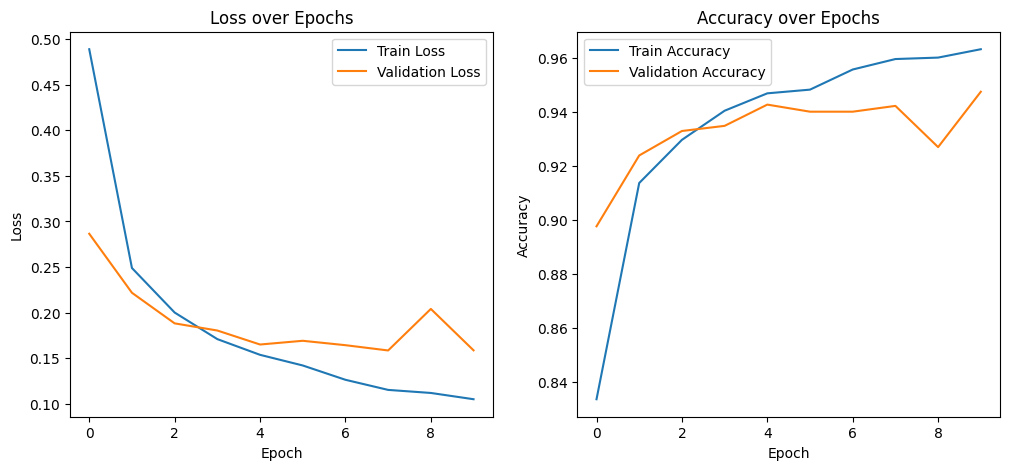

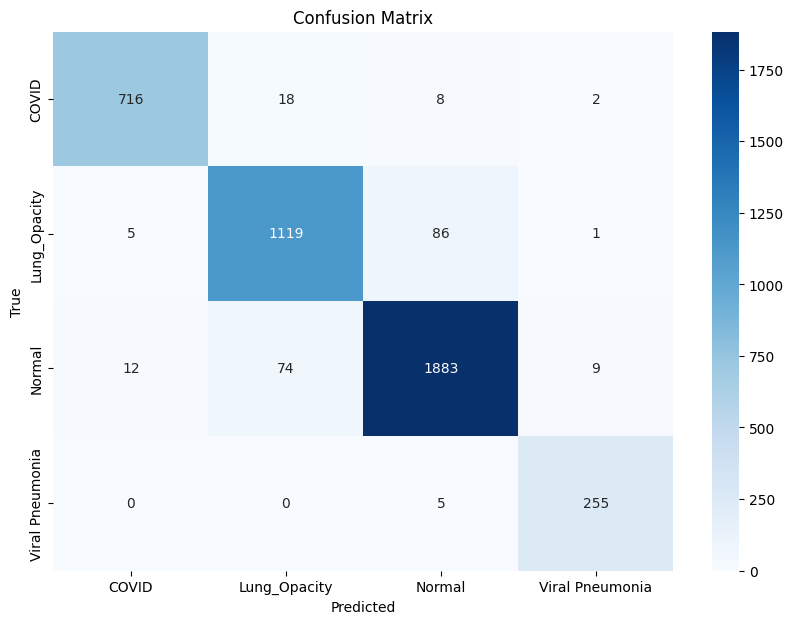

CPU times: total: 1h 11min 24s
Wall time: 1h 17min 11s


In [13]:
%%time

model, train_losses, val_losses, train_accuracies, val_accuracies = train_model(model, criterion, optimizer, scheduler, num_epochs=10)

In [14]:
# Предсказания на тестовой выборке
class TestDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.filenames = sorted(os.listdir(root_dir))

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, idx):
        img_name = os.path.join(self.root_dir, self.filenames[idx])
        image = Image.open(img_name)
        image = image.convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image

In [15]:
root_dir = 'Test'
test_dataset = TestDataset(root_dir, test_transform)
test_dataloader = DataLoader(test_dataset, batch_size, shuffle=False)

model.eval()
predictions = []
for images in test_dataloader:
    images = images.to(device)
    with torch.no_grad():
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
    predictions.extend(preds.cpu().numpy())

In [16]:
predictions_df = pd.DataFrame({'ImageId': range(1, len(predictions) + 1), 'Label': predictions})
predictions_df

,ImageId,Label
0,1,0
1,2,3
2,3,0
3,4,0
4,5,2
...,...,...
195,196,1
196,197,2
197,198,2
198,199,0


In [17]:
predictions_df.to_csv('submission.csv', index=False)